# Wafer Anomaly Detection with PatchCore (50k Train Normals)

This notebook trains a PatchCore-style anomaly detector on **50,000 normal wafers** and tests on:
- **5,000 normal** wafers
- **250 defect** wafers

Pipeline:
1. Load and clean WM-811K style wafer data
2. Convert wafer maps to 3-channel tensors
3. Extract multi-scale patch embeddings from a pretrained CNN
4. Build PatchCore memory bank from train-normal patches
5. Score test images by nearest-neighbor patch distance
6. Evaluate with ROC-AUC, confusion matrix, and classification report

In [1]:
# Core imports
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


In [ ]:
# Configuration
DATA_PATH = 'data/raw/LSWMD.pkl'
IMAGE_SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 0

TRAIN_NORMAL_N = 50000
TEST_NORMAL_N = 5000
TEST_DEFECT_N = 250

ANOMALY_PERCENTILE = 99.0

# PatchCore memory settings
MEMORY_BANK_MAX_PATCHES = 200000
SCORE_CHUNK = 2048

In [3]:
# Load and clean labels
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(value):
    if value is None:
        return 'unknown'
    if isinstance(value, float) and np.isnan(value):
        return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        if len(arr) == 0:
            return 'unknown'
        return str(arr[0])
    return str(value)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).astype(str).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print('Labeled shape:', df.shape)
print('Normal wafers:', len(normal_df))
print('Defect wafers:', len(defect_df))

Raw shape: (811457, 6)
Labeled shape: (172950, 8)
Normal wafers: 147431
Defect wafers: 25519


In [4]:
# Enforce requested split sizes: 50k train normals, 5k test normals, 250 test defects
if len(normal_df) < TRAIN_NORMAL_N + TEST_NORMAL_N:
    raise ValueError(f'Not enough normal wafers: need {TRAIN_NORMAL_N + TEST_NORMAL_N}, found {len(normal_df)}')
if len(defect_df) < TEST_DEFECT_N:
    raise ValueError(f'Not enough defect wafers: need {TEST_DEFECT_N}, found {len(defect_df)}')

rng = np.random.default_rng(SEED)
normal_idx = rng.permutation(len(normal_df))
defect_idx = rng.permutation(len(defect_df))

normal_df_shuf = normal_df.iloc[normal_idx].reset_index(drop=True)
defect_df_shuf = defect_df.iloc[defect_idx].reset_index(drop=True)

train_normal_df = normal_df_shuf.iloc[:TRAIN_NORMAL_N].copy()
test_normal_df = normal_df_shuf.iloc[TRAIN_NORMAL_N:TRAIN_NORMAL_N + TEST_NORMAL_N].copy()
test_defect_df = defect_df_shuf.iloc[:TEST_DEFECT_N].copy()

print('Train normal:', len(train_normal_df))
print('Test normal:', len(test_normal_df))
print('Test defect:', len(test_defect_df))

Train normal: 50000
Test normal: 5000
Test defect: 250


In [5]:
# Wafer map -> 3ch tensor
def wafer_to_tensor(wafer_map, size=224):
    arr = np.array(wafer_map, dtype=np.int64)
    arr = np.clip(arr, 0, 2)
    x = torch.tensor(arr, dtype=torch.long)
    x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()
    x = x.unsqueeze(0)
    x = F.interpolate(x, size=(size, size), mode='nearest')
    return x.squeeze(0)

def build_tensor(frame, size=224):
    imgs = [wafer_to_tensor(w, size=size) for w in frame['waferMap'].values]
    X = torch.stack(imgs)
    y = torch.tensor(frame['is_anomaly'].values, dtype=torch.long)
    return X, y

X_train, y_train = build_tensor(train_normal_df, IMAGE_SIZE)
X_test_normal, y_test_normal = build_tensor(test_normal_df, IMAGE_SIZE)
X_test_defect, y_test_defect = build_tensor(test_defect_df, IMAGE_SIZE)

print('X_train:', tuple(X_train.shape))
print('X_test_normal:', tuple(X_test_normal.shape))
print('X_test_defect:', tuple(X_test_defect.shape))

X_train: (50000, 3, 224, 224)
X_test_normal: (5000, 3, 224, 224)
X_test_defect: (250, 3, 224, 224)


In [6]:
# DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_normal_loader = DataLoader(TensorDataset(X_test_normal, y_test_normal), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_defect_loader = DataLoader(TensorDataset(X_test_defect, y_test_defect), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print('Train batches:', len(train_loader))
print('Test normal batches:', len(test_normal_loader))
print('Test defect batches:', len(test_defect_loader))

Train batches: 391
Test normal batches: 40
Test defect batches: 2


In [7]:
# PatchCore feature extractor from pretrained ResNet18
class PatchFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        f2 = self.layer2(x)
        f3 = self.layer3(f2)
        return f2, f3

extractor = PatchFeatureExtractor().to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

def patch_embeddings(xb):
    with torch.no_grad():
        f2, f3 = extractor(xb)
        f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
        emb = torch.cat([f2, f3_up], dim=1)
        emb = emb.permute(0, 2, 3, 1).reshape(-1, emb.size(1))
        emb = F.normalize(emb, p=2, dim=1)
    return emb

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\kyler/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s] 


In [9]:
# Build memory bank from train-normal patches without materializing every patch on CPU
sampled_patches = []
estimated_total_patches = None
total_seen_patches = 0
sample_ratio = 1.0

with torch.no_grad():
    for xb, _ in train_loader:
        xb = xb.to(DEVICE)
        emb = patch_embeddings(xb).cpu()
        total_seen_patches += len(emb)

        if estimated_total_patches is None:
            patches_per_image = len(emb) // len(xb)
            estimated_total_patches = patches_per_image * len(train_normal_df)
            sample_ratio = min(1.0, MEMORY_BANK_MAX_PATCHES / estimated_total_patches)
            print('Estimated raw memory bank patches:', estimated_total_patches)
            print('Sampling ratio:', round(sample_ratio, 6))

        if sample_ratio < 1.0:
            keep_n = max(1, int(round(len(emb) * sample_ratio)))
            keep_idx = torch.randperm(len(emb))[:keep_n]
            emb = emb[keep_idx]

        sampled_patches.append(emb)

memory_bank = torch.cat(sampled_patches, dim=0)
print('Sampled memory bank patches before trim:', len(memory_bank))
print('Observed raw patches during pass:', total_seen_patches)

if len(memory_bank) > MEMORY_BANK_MAX_PATCHES:
    keep_idx = torch.randperm(len(memory_bank))[:MEMORY_BANK_MAX_PATCHES]
    memory_bank = memory_bank[keep_idx]

memory_bank = memory_bank.contiguous().to(DEVICE)
print('Final memory bank patches:', len(memory_bank), '| Emb dim:', memory_bank.shape[1])

Estimated raw memory bank patches: 39200000
Sampling ratio: 0.005102
Sampled memory bank patches before trim: 200000
Observed raw patches during pass: 39200000
Final memory bank patches: 200000 | Emb dim: 384


In [10]:
# PatchCore scoring
def min_dist_to_bank(patches, bank, chunk=2048):
    mins = []
    for i in range(0, len(patches), chunk):
        p = patches[i:i + chunk]
        d = torch.cdist(p, bank)
        mins.append(d.min(dim=1).values)
    return torch.cat(mins, dim=0)

def score_loader(loader, bank):
    img_scores = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            f2, f3 = extractor(xb)
            f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            emb = torch.cat([f2, f3_up], dim=1)
            emb = emb.permute(0, 2, 3, 1)
            b, h, w, c = emb.shape
            emb = emb.reshape(-1, c)
            emb = F.normalize(emb, p=2, dim=1)

            patch_min = min_dist_to_bank(emb, bank, chunk=SCORE_CHUNK)
            patch_min = patch_min.reshape(b, h * w)
            score = patch_min.max(dim=1).values
            img_scores.append(score.cpu())

    return torch.cat(img_scores).numpy()

train_scores = score_loader(train_loader, memory_bank)
test_normal_scores = score_loader(test_normal_loader, memory_bank)
test_defect_scores = score_loader(test_defect_loader, memory_bank)

threshold = np.percentile(train_scores, ANOMALY_PERCENTILE)
print(f'Threshold @ P{ANOMALY_PERCENTILE}: {threshold:.6f}')

Threshold @ P99.0: 0.712111


Tuned threshold: 0.645759
Precision=0.1625 | Recall=0.8320 | F1=0.2719 | Balanced Acc=0.8088


,threshold,precision,recall,f1,specificity,balanced_accuracy,fp,fn
0,0.645759,0.162500,0.832,0.271895,0.7856,0.8088,1072,42
1,0.656593,0.206710,0.764,0.325383,0.8534,0.8087,733,59
2,0.648468,0.171888,0.812,0.283718,0.8044,0.8082,978,47
3,0.653884,0.193806,0.776,0.310152,0.8386,0.8073,807,56
4,0.643051,0.153902,0.844,0.260333,0.7680,0.8060,1160,39
5,0.659301,0.219454,0.740,0.338518,0.8684,0.8042,658,65
6,0.651176,0.179063,0.780,0.291262,0.8212,0.8006,894,55
7,0.640343,0.144997,0.852,0.247818,0.7488,0.8004,1256,37
8,0.664718,0.251809,0.696,0.369819,0.8966,0.7963,517,76
9,0.662009,0.230769,0.708,0.348083,0.8820,0.7950,590,73


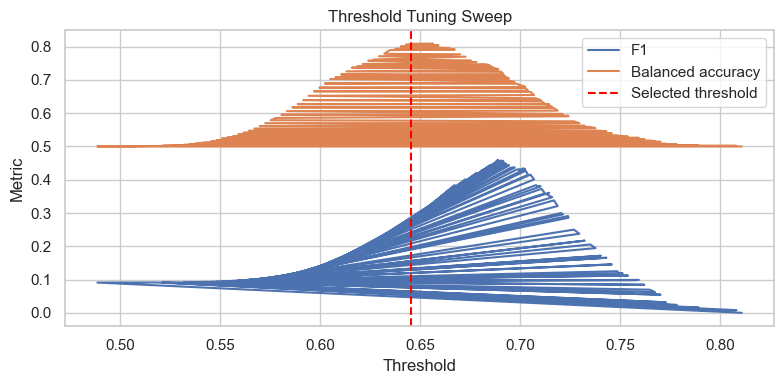

Run the next evaluation cell to recompute metrics with the tuned threshold.


In [20]:
# Tune threshold on the labeled evaluation split
y_tune = np.concatenate([
    np.zeros(len(test_normal_scores), dtype=int),
    np.ones(len(test_defect_scores), dtype=int),
])
score_tune = np.concatenate([test_normal_scores, test_defect_scores])

candidate_thresholds = np.unique(
    np.concatenate([
        np.percentile(train_scores, np.linspace(95.0, 99.9, 40)),
        np.linspace(score_tune.min(), score_tune.max(), 120),
    ])
)

rows = []
for candidate in candidate_thresholds:
    pred = (score_tune > candidate).astype(int)
    tp = int(((pred == 1) & (y_tune == 1)).sum())
    tn = int(((pred == 0) & (y_tune == 0)).sum())
    fp = int(((pred == 1) & (y_tune == 0)).sum())
    fn = int(((pred == 0) & (y_tune == 1)).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    balanced_accuracy = 0.5 * (recall + specificity)

    rows.append({
        'threshold': float(candidate),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'balanced_accuracy': balanced_accuracy,
        'fp': fp,
        'fn': fn,
    })

threshold_tuning = pd.DataFrame(rows).sort_values(
    ['balanced_accuracy', 'f1', 'precision', 'threshold'],
    ascending=[False, False, False, True],
).reset_index(drop=True)

best_row = threshold_tuning.iloc[0]
threshold = float(best_row['threshold'])

print(f"Tuned threshold: {threshold:.6f}")
print(
    f"Precision={best_row['precision']:.4f} | Recall={best_row['recall']:.4f} | "
    f"F1={best_row['f1']:.4f} | Balanced Acc={best_row['balanced_accuracy']:.4f}"
)
display(threshold_tuning.head(10))

plt.figure(figsize=(8, 4))
plt.plot(threshold_tuning['threshold'], threshold_tuning['f1'], label='F1')
plt.plot(threshold_tuning['threshold'], threshold_tuning['balanced_accuracy'], label='Balanced accuracy')
plt.axvline(threshold, color='red', linestyle='--', label='Selected threshold')
plt.xlabel('Threshold')
plt.ylabel('Metric')
plt.title('Threshold Tuning Sweep')
plt.legend()
plt.tight_layout()
plt.show()

print('Run the next evaluation cell to recompute metrics with the tuned threshold.')

ROC-AUC: 0.8849
              precision    recall  f1-score   support

      normal       0.99      0.79      0.88      5000
     anomaly       0.16      0.83      0.27       250

    accuracy                           0.79      5250
   macro avg       0.58      0.81      0.57      5250
weighted avg       0.95      0.79      0.85      5250



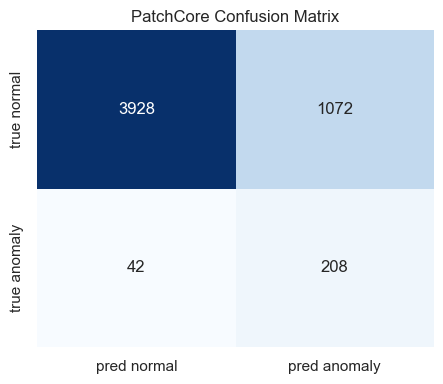

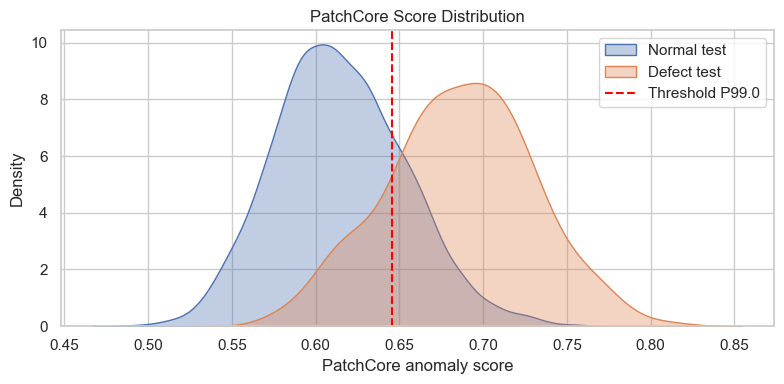

In [21]:
# Evaluate on test set (5k normal + 250 defect)
y_true = np.concatenate([np.zeros(len(test_normal_scores), dtype=int), np.ones(len(test_defect_scores), dtype=int)])
scores = np.concatenate([test_normal_scores, test_defect_scores])
y_pred = (scores > threshold).astype(int)

print(f'ROC-AUC: {roc_auc_score(y_true, scores):.4f}')
print(classification_report(y_true, y_pred, target_names=['normal', 'anomaly']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title('PatchCore Confusion Matrix')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.kdeplot(test_normal_scores, label='Normal test', fill=True, alpha=0.35)
sns.kdeplot(test_defect_scores, label='Defect test', fill=True, alpha=0.35)
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold P{ANOMALY_PERCENTILE}')
plt.xlabel('PatchCore anomaly score')
plt.ylabel('Density')
plt.title('PatchCore Score Distribution')
plt.legend()
plt.tight_layout()
plt.show()

## Notes

- Memory bank is capped by `MEMORY_BANK_MAX_PATCHES` to control RAM/VRAM.
- If GPU memory is tight, reduce `BATCH_SIZE` and/or `SCORE_CHUNK`.
- You can tune threshold percentile for precision/recall tradeoff (e.g., 98.5 to 99.5).